In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

df = pd.read_csv('../data/ph_household_survey.csv')

## Q1 
- the shape of dataset is 1200 rows and 26 columns 
- most of the dtypes are float, str, and int
- the total missing values in the dataset is 1525
- as for the column that has the highest missing count, it is health insurance with 30.33% missing val, internet_access with 29.75% and electricity_source with 21.58%

In [2]:
df.describe()

,survey_year,age,years_of_schooling,monthly_income_php,household_size,num_children,food_insecurity_score,bmi,mental_health_score,dist_to_health_facility_km,received_gov_aid,gov_aid_amount_php
count,1200.000000,1200.000000,1200.000000,1040.000000,1200.000000,1200.000000,1200.00000,1065.000000,1064.000000,1200.000000,1200.000000,1200.000000
mean,2020.499167,34.764167,12.914167,19305.762500,4.314167,1.773333,2.95750,24.482347,8.105263,6.199167,0.433333,565.833333
std,1.711951,11.757923,4.499482,19772.939305,1.778980,1.378479,1.09088,4.139972,4.540215,4.947990,0.495742,769.139531
min,2018.000000,15.000000,0.000000,-999.000000,1.000000,0.000000,1.00000,12.500000,0.000000,0.000000,0.000000,0.000000
25%,2019.000000,26.000000,10.000000,5801.000000,3.000000,1.000000,2.00000,21.400000,5.000000,2.700000,0.000000,0.000000
50%,2021.000000,35.000000,13.000000,15444.500000,4.000000,2.000000,3.00000,24.400000,8.000000,5.300000,0.000000,0.000000
75%,2022.000000,42.000000,17.000000,26186.250000,5.000000,3.000000,4.00000,27.500000,11.000000,8.200000,1.000000,1000.000000
max,2023.000000,73.000000,20.000000,170391.000000,10.000000,7.000000,5.00000,35.600000,25.000000,33.700000,1.000000,3000.000000


In [3]:
df.shape

(1200, 26)

In [4]:
df.info

<bound method DataFrame.info of      respondent_id  survey_year       region              province     sex  \
0        PH-002018         2022   Region III   Region III Province    Male   
1        PH-002019         2018   Region VII                  Cebu  Female   
2        PH-002020         2023     Region V     Region V Province    Male   
3        PH-002021         2018  Region IV-B  Region IV-B Province  Female   
4        PH-002022         2018    Region XI          Davao de Oro  Female   
...            ...          ...          ...                   ...     ...   
1195     PH-003213         2018   Region XII   Region XII Province  Female   
1196     PH-003214         2023  Region IV-B  Region IV-B Province    Male   
1197     PH-003215         2023  Region IV-B  Region IV-B Province    Male   
1198     PH-003216         2018    Region II    Region II Province  Female   
1199     PH-003217         2021    Region VI    Region VI Province  Female   

      age        civil_status  

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_total = missing.sum()
print(f"Total Missing Values: {missing_total}")
missing_pct = ((missing / len(df)) * 100).round(2)

missing_summary = pd.DataFrame({'Missing_Count': missing, 'Missing_Percentage': missing_pct})

print(missing_summary)

Total Missing Values: 1525
                            Missing_Count  Missing_Percentage
health_insurance                      364               30.33
internet_access                       357               29.75
electricity_source                    259               21.58
monthly_income_php                    160               13.33
mental_health_score                   136               11.33
bmi                                   135               11.25
toilet_facility                       114                9.50
region                                  0                0.00
respondent_id                           0                0.00
survey_year                             0                0.00
employment_status                       0                0.00
years_of_schooling                      0                0.00
education_level                         0                0.00
civil_status                            0                0.00
age                                     0  

In [6]:
missing_only = missing_summary[missing_summary['Missing_Count'] > 0]
print("Columns with Missing Values:")
print(missing_only)

Columns with Missing Values:
                     Missing_Count  Missing_Percentage
health_insurance               364               30.33
internet_access                357               29.75
electricity_source             259               21.58
monthly_income_php             160               13.33
mental_health_score            136               11.33
bmi                            135               11.25
toilet_facility                114                9.50


## Q2 

-Upon inspecting the monthly_income_php variable, a minimum value of -999 was identified. This was determined to be a placeholder for missing responses. To maintain the statistical integrity of the income distribution, these records were recoded to NaN. This allows for accurate calculation of central tendency and dispersion without the skewing effect of extreme negative outliers.

In [7]:
df_copy = df.copy()

df_copy.loc[df_copy['monthly_income_php'] < 0, 'monthly_income_php'] = np.nan
df_copy.head()

,respondent_id,survey_year,region,province,sex,age,civil_status,education_level,years_of_schooling,employment_status,occupation_type,monthly_income_php,household_size,num_children,housing_type,water_source,toilet_facility,electricity_source,internet_access,health_insurance,food_insecurity_score,bmi,mental_health_score,dist_to_health_facility_km,received_gov_aid,gov_aid_amount_php
0,PH-002018,2022,Region III,Region III Province,Male,40,Separated/Annulled,College,15,Employed,None/Informal,22405.0,5,4,Owned - Concrete,Communal Faucet,Pit Latrine,Meralco/Electric Coop,NaN,PhilHealth Only,2,23.5,15.0,7.3,0,0
1,PH-002019,2018,Region VII,Cebu,Female,29,Live-in,College,17,Employed,Education,33709.0,3,1,Owned - Concrete,Piped/NAWASA,Shared Toilet,Meralco/Electric Coop,Mobile Data Only,PhilHealth Only,3,16.5,0.0,3.3,1,1000
2,PH-002020,2023,Region V,Region V Province,Male,22,Live-in,Elementary,6,Employed,Government,29394.0,3,0,Owned - Concrete,Piped/NAWASA,Water-sealed/Flush,Meralco/Electric Coop,Mobile Data Only,PhilHealth Only,4,23.6,8.0,0.7,0,0
3,PH-002021,2018,Region IV-B,Region IV-B Province,Female,28,Married,High School,11,Retired,Transport/Logistics,10346.0,2,2,Rented,Shallow Well,Shared Toilet,Solar,NaN,PhilHealth Only,2,23.3,4.0,10.6,0,0
4,PH-002022,2018,Region XI,Davao de Oro,Female,34,Live-in,Vocational/Tech,14,Employed,Manufacturing,12905.0,6,0,Rented,Piped/NAWASA,Pit Latrine,NaN,Mobile Data Only,PhilHealth Only,3,16.3,1.0,5.6,1,2000


## Q3
- Upon expecting theres no notable errors on both columnns and still proceed with their given values
- shows plots and distribution

------------EMPLOYMENT STATUS ----------------------


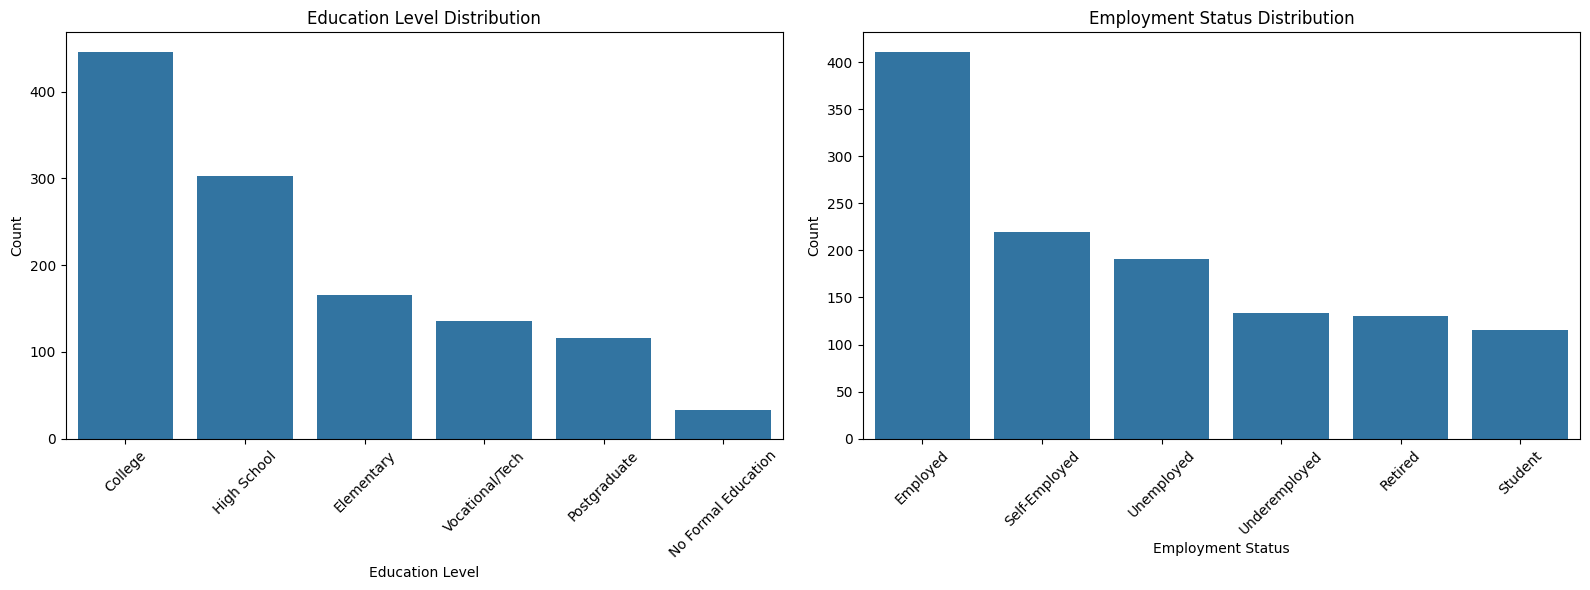

In [8]:

# df_copy.describe()

# df_copy.info()

import os

os.makedirs('../output', exist_ok=True)


fig, axes = plt.subplots(1, 2, figsize=(16,6))

# print("------------EDUCATION LEVEL ----------------------")
edu_counts = df_copy['education_level'].value_counts(dropna=False)
sns.barplot(x=edu_counts.index, y=edu_counts.values, ax=axes[0])
axes[0].set_title('Education Level Distribution')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

print("------------EMPLOYMENT STATUS ----------------------")
employment_counts = df_copy['employment_status'].value_counts(dropna=False)
sns.barplot(x=employment_counts.index, y=employment_counts.values, ax=axes[1])
axes[1].set_title('Employment Status Distribution')
axes[1].set_xlabel('Employment Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

output_path = '../output/q3.png'
plt.savefig(output_path)
plt.show()

## Q4 

  - Used `.describe()` to inspect min/max values and overall 
  distribution statistics
  - Applied boolean filtering `(age < 15) | (age > 85)` to   
  identify any out-of-range records
  - Plotted a histogram with KDE overlay to visualize the age
   distribution

Age Range: 15 - 73
Out of Range Age Values:
 0


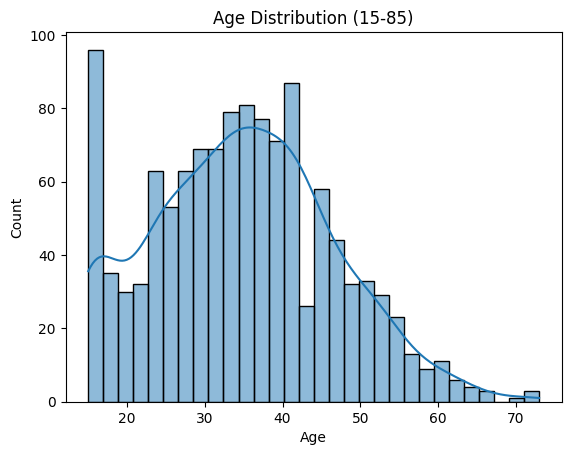

In [9]:
df_copy['age'].describe() 
# given with the describe i can see that there are no below 15 and aboc 85 on age so over all its good for the given problem

print(f"Age Range: {df_copy['age'].min()} - {df_copy['age'].max()}")
out_of_range = df_copy[(df_copy['age'] < 15) | (df_copy['age'] > 85)]
#this confirms if there are over the age range values or not
print(f"Out of Range Age Values:\n {len(out_of_range)}")


val_ages = df_copy[(df_copy['age'] >= 15) & (df_copy['age'] <= 85)]
sns.histplot(val_ages['age'], bins=30, kde=True)
plt.xlabel('Age')
plt.title('Age Distribution (15-85)')
plt.savefig('../output/q4.png')
plt.show()

## Q5 

- The missingness is MNAR. 
- Null income rates are heavily concentrated among
- Unemployed respondents (~49%) and students (~10%),
- while employed groups have less than 7% missing. This indicates that respondents with no stable income are more likely to leave the field blank — the missingness is structurally tied to the value itself (employment condition).


np.int64(160)

employment_status
Employed         411
Self-Employed    219
Unemployed       191
Underemployed    134
Retired          130
Student          115
Name: count, dtype: int64

,employment_status,total_count,null_count,zero_income_count,null_percentage,zero_income_percentage
0,Employed,411,28,0,6.81,0.00
1,Retired,130,13,0,10.00,0.00
2,Self-Employed,219,6,0,2.74,0.00
3,Student,115,11,100,9.57,86.96
4,Underemployed,134,8,0,5.97,0.00
5,Unemployed,191,94,92,49.21,48.17


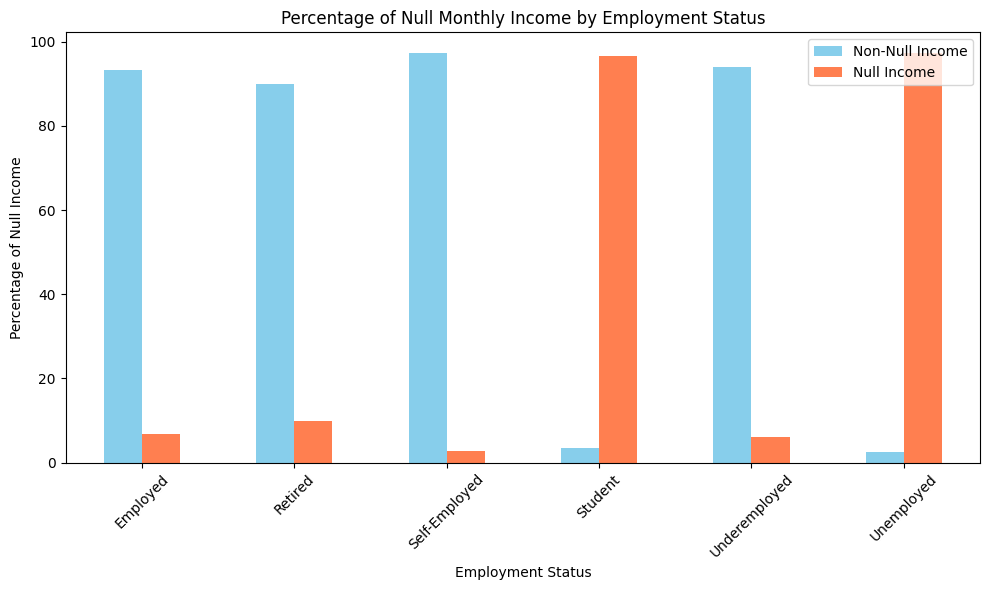

In [10]:
# df_copy['monthly_income_php'].describe()
# display(df_copy['monthly_income_php'].isnull().sum())
# display(df_copy['monthly_income_php'].notnull().sum())
# df_copy['income_null'] = df_copy['monthly_income_php'].isnull().astype(int)
df_raw = df.copy()

display(df_raw['monthly_income_php'].isnull().sum())
display(df_raw['employment_status'].value_counts(dropna=False))


grouped = df_raw.groupby('employment_status').agg(total_count=('employment_status', 'count'),
                                                null_count=('monthly_income_php', lambda x: x.isnull().sum()),
                                                zero_income_count=('monthly_income_php', lambda x: (x == 0).sum())).reset_index()

df_raw['income_null'] = (df_raw['monthly_income_php'].isnull() | (df_raw['monthly_income_php'] == 0)).astype(int)
grouped['null_percentage'] = (grouped['null_count'] / grouped['total_count'] * 100).round(2)
grouped['zero_income_percentage'] = (grouped['zero_income_count'] / grouped['total_count'] * 100).round(2)
display(grouped)


crosstab_pct = pd.crosstab(df_raw['employment_status'], df_raw['income_null'], normalize='index') * 100
crosstab_pct.columns = ['Non-Null Income', 'Null Income']

crosstab_pct.plot(kind='bar', color=['skyblue', 'coral'], figsize=(10,6))
plt.title('Percentage of Null Monthly Income by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Percentage of Null Income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../output/q5.png', dpi=300)
plt.show()

## Q6
- Raw distribution is right-skewed (few high earners pull the mean     
above median)
- Log-transform makes it more symmetric/normal
- Log-transforming income is common because income follows a multiplicative process, not additive — and it compresses large ranges into a scale where percentage differences matter more than absolute differences


count      1006.000000
mean      19992.006958
std       19742.761954
min           0.000000
25%        7025.750000
50%       15822.500000
75%       26640.250000
max      170391.000000
Name: monthly_income_php, dtype: float64

np.int64(194)

np.int64(1006)

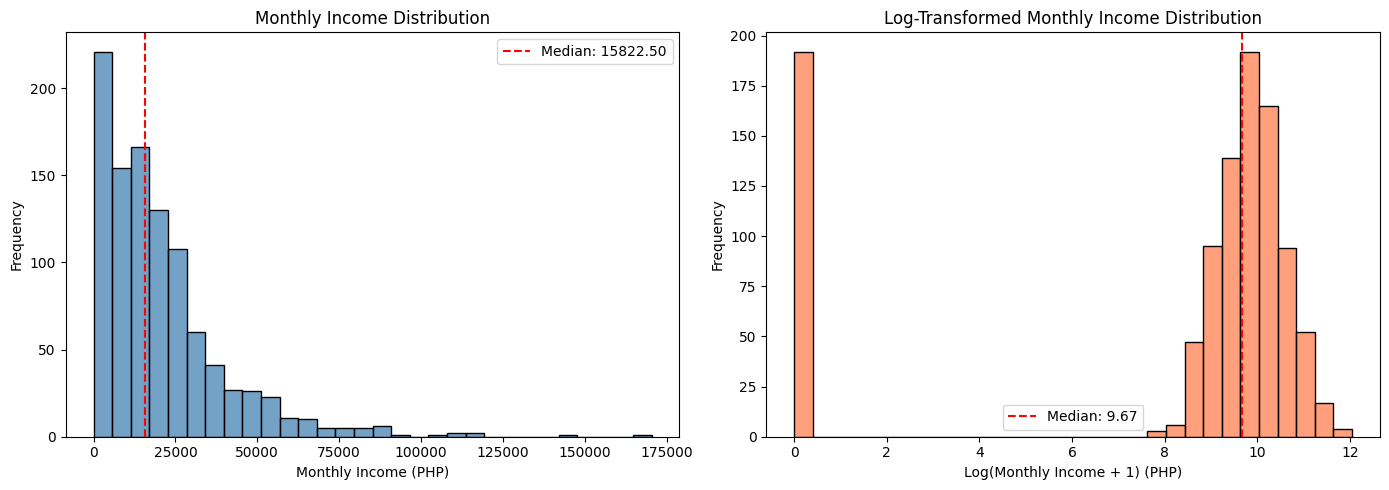

Skewness (raw): 2.07
Skewness (log): -1.48


In [11]:
display(df_copy['monthly_income_php'].describe())
display(df_copy['monthly_income_php'].isnull().sum())
display(df_copy['monthly_income_php'].notnull().sum())


fig, axes = plt.subplots(1, 2, figsize=(14,5))


sns.histplot(df_copy['monthly_income_php'].dropna(), bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Monthly Income Distribution')
axes[0].set_xlabel('Monthly Income (PHP)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_copy['monthly_income_php'].median(), color='red', linestyle='--', label=f'Median: {df_copy['monthly_income_php'].median():.2f}')
axes[0].legend()


income_log = np.log1p(df_copy['monthly_income_php'].dropna())
sns.histplot(income_log, bins=30, ax=axes[1], color='coral')
axes[1].set_title('Log-Transformed Monthly Income Distribution')
axes[1].set_xlabel('Log(Monthly Income + 1) (PHP)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(income_log.median(), color='red', linestyle='--', label=f'Median: {income_log.median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/q6.png', dpi=150)
plt.show()

print(f"Skewness (raw): {df_copy['monthly_income_php'].skew():.2f}")   
print(f"Skewness (log): {income_log.skew():.2f}")

**Q7.** Plot a countplot of `region`. Which region has the most respondents? Is this distribution roughly what you'd expect for a national survey, or does it look imbalanced?

- the data shown that region 11 has the highest number of surveyed respondents and by looking at the graph it is slightly imbalanced but i feel like this survey is what will look mostly with the national survey. 
- considering the number of population on NCR compared to provinces, i think this proves the imbalance and inaccuarete data. We can say that its incomplete or the survey is not focused on region


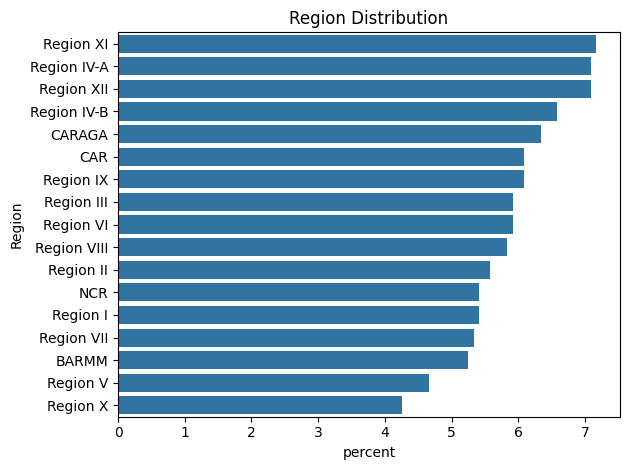

In [12]:
# df_copy['region'].value_counts(dropna=False)

sns.countplot(y='region', data=df_copy, order=df_copy['region'].value_counts().index, stat='percent')
plt.ylabel('Region')
plt.title('Region Distribution')
plt.tight_layout()
plt.savefig('../output/q7.png', dpi=150)
plt.show()

**Q8.** Plot the distribution of `mental_health_score`. Does it look roughly normal? Note the range and what a higher score means in this context. Overlay a KDE curve.

- The mental_health_score distribution is roughly bell-shaped but slightly right-skewed, so it is only approximately normal
- Scores span about 0 to 25 (within the expected 0–27 scale)
- most respondents are in the low-to-mid range while few has some very high score
- Im not fond of mental health score and how is it actually measured


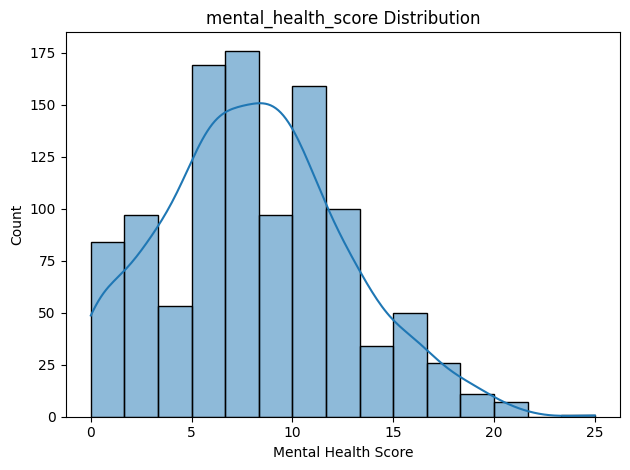

In [13]:
df_copy['mental_health_score'].describe()
sns.histplot(data=df_copy, x='mental_health_score', bins=15, kde=True)
plt.xlabel('Mental Health Score')
plt.title('mental_health_score Distribution')
plt.tight_layout()
plt.savefig('../output/q8.png', dpi=150)
plt.show()

**Q9.** Plot a countplot of `education_level` ordered from lowest to highest level (not alphabetically). What is the most common education level in the dataset?

- the most common education level is college, the lowest if the no formal education

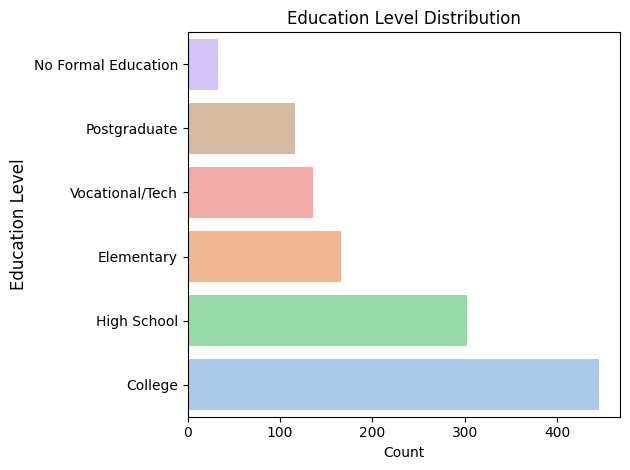

In [14]:

# df_copy['education_level'].value_counts(dropna=False).plot(kind='bar', color='mediumpurple')

sns.countplot(data=df_copy, y='education_level', order=df_copy['education_level'].value_counts().index[::-1], palette='pastel', hue='education_level')
plt.title('Education Level Distribution')
plt.xlabel('Count')
plt.ylabel('Education Level',fontsize=12)
plt.tight_layout()
plt.savefig('../output/q9.png', dpi=150)
plt.show()

**Q10.** `food_insecurity_score` runs from 1 to 5. Plot its distribution as both a countplot and a boxplot. What does the median tell you about the sample?

- so upon expecting both plots the median should actually fall to count 3 however the median on countplot is a higher compared to the countplot so gotta negate 1
- based on googles and searching on it, this cases is quite common since the boxplot treats it as list so instead of numerican it count as string or object in a list where it starts to index 0. so the count 3 on the bar is index at 2. thats why the count axv line is at 4 since the right median is 3 and if that is in index it will be at count 4. think of it as doing for loop [1,2,3,4,5] for loop starts at 0 and you know it
- as for boxplot its numeric so theres is no difference


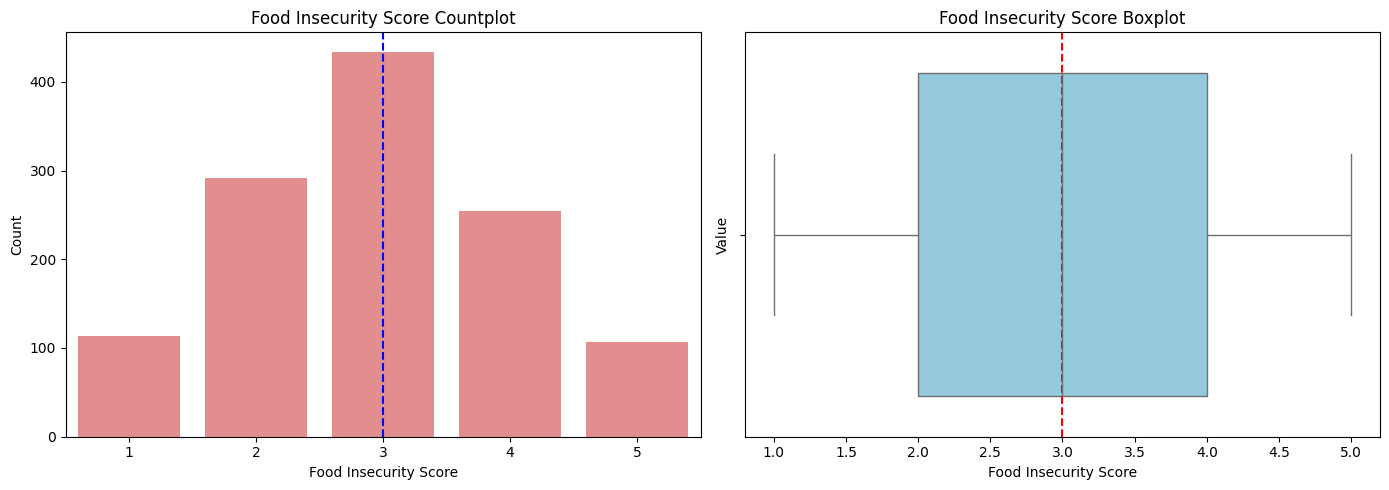

In [15]:
# df_copy['food_insecurity_score'].value_counts(dropna=False).plot(kind='bar', color='lightcoral')

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(data=df_copy, x='food_insecurity_score', ax=axes[0], color='lightcoral' )
axes[0].set_title('Food Insecurity Score Countplot')
axes[0].set_xlabel('Food Insecurity Score')
axes[0].set_ylabel('Count')
axes[0].axvline(df_copy['food_insecurity_score'].median() -1, color='blue', linestyle='--', label=f'Median: {df_copy['food_insecurity_score'].median():.2f}')


sns.boxplot(data=df_copy, x='food_insecurity_score', ax=axes[1], color='skyblue')
axes[1].set_title('Food Insecurity Score Boxplot')
axes[1].set_xlabel('Food Insecurity Score')
axes[1].set_ylabel('Value')
axes[1].axvline(df_copy['food_insecurity_score'].median(), color='red', linestyle='dashed', label=f"Median: {df_copy['food_insecurity_score'].median():.2f}")

plt.tight_layout()
plt.savefig('../output/q10.png', dpi=150)
plt.show()

**Q11.** Plot a boxplot of `monthly_income_php` grouped by `education_level` (ordered lowest to highest). Does income increase with education level? Are there outliers in any group? Use log-scale on the y-axis.

- firstly i tried to use just to list the educ order wher i could still the outlier but decided to rank it from lowest to highest manually since thats the problem
- since i dont like using boxplot and i am more biased to use sstripplot to look if there are outliers
- from the data shown there are some outliers on elementary, highschool, and college. some earns a lot from college and elementary and somehow there are bottom outliers for all of it


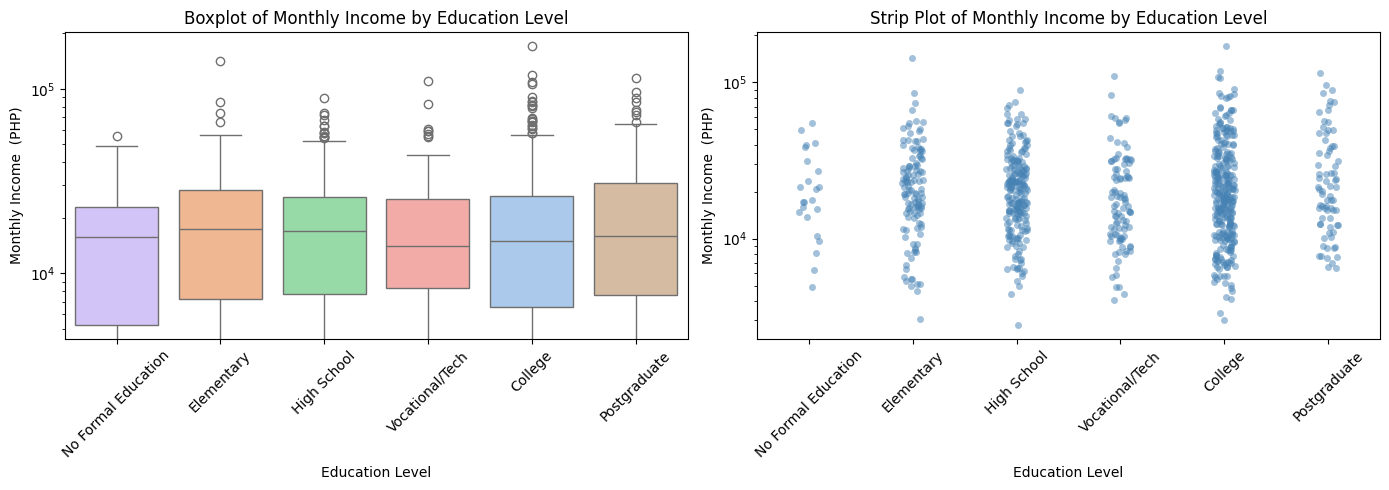

In [16]:
educ_order = educ_order = [
    'No Formal Education', 
    'Elementary', 
    'High School', 
    'Vocational/Tech', 
    'College', 
    'Postgraduate'
]
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df_copy, order=educ_order, x='education_level', y='monthly_income_php', ax=axes[0], palette='pastel', hue='education_level')
axes[0].set_yscale('log')
axes[0].xaxis.set_tick_params(rotation=45)
axes[0].set_title('Boxplot of Monthly Income by Education Level')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Monthly Income  (PHP)')


sns.stripplot(data=df_copy, order=educ_order, x='education_level', y='monthly_income_php', ax=axes[1], color='steelblue', alpha=0.5, jitter=True)
axes[1].set_yscale('log')
axes[1].xaxis.set_tick_params(rotation=45)
axes[1].set_title('Strip Plot of Monthly Income by Education Level')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Monthly Income  (PHP)')

plt.tight_layout()
plt.savefig('../output/q11.png', dpi=150)
plt.show()

**Q13.** Compare `mental_health_score` distributions between `survey_year` 2019 and 2021 using side-by-side boxplots or violin plots. Do you see a difference? What might explain it?
- from the violin plot, 2021 scores are generally higher than 2019, so there is a visible difference between the two years
- the center/median of 2021 is higher, and more values are concentrated at higher mental health scores compared to 2019
- since higher mental_health_score means worse symptoms, this suggests respondents in 2021 had more stress/distress
- possible reason is the pandemic period effect (covid years), where people had more anxiety due to health risk, income problems, and   isolation

Median Score 2019: 7.0
Median Score 2021: 9.0


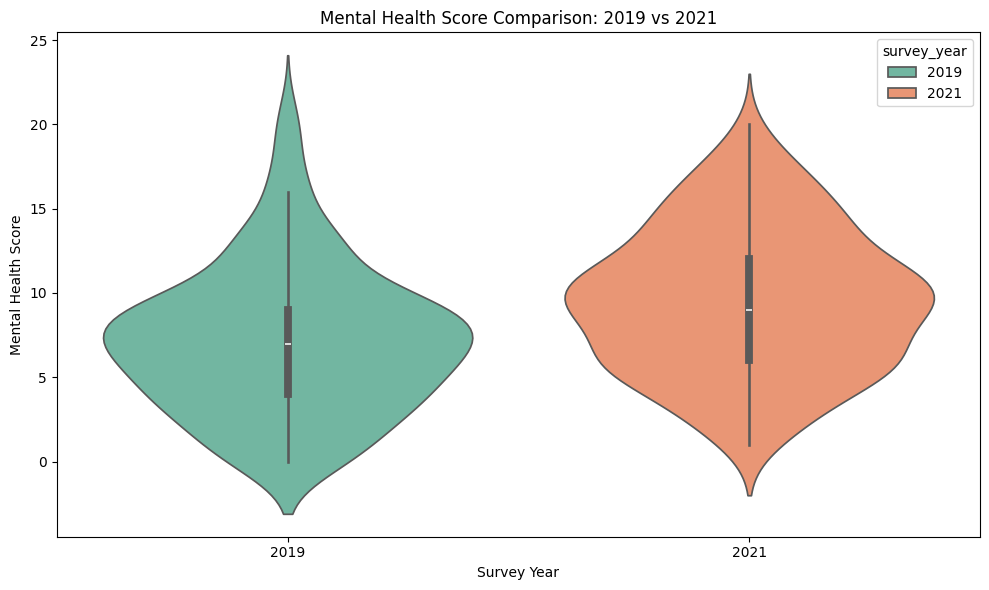

In [18]:
# Filter data for only 2019 and 2021
df_19_21 = df_copy[df_copy['survey_year'].isin([2019, 2021])]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_19_21, x='survey_year', y='mental_health_score', palette='Set2', inner='box', hue='survey_year')

plt.title('Mental Health Score Comparison: 2019 vs 2021')
plt.xlabel('Survey Year')
plt.ylabel('Mental Health Score')

# Let's print out the medians to back up our observation
median_19 = df_19_21[df_19_21['survey_year'] == 2019]['mental_health_score'].median()
median_21 = df_19_21[df_19_21['survey_year'] == 2021]['mental_health_score'].median()
print(f"Median Score 2019: {median_19}")
print(f"Median Score 2021: {median_21}")

plt.tight_layout()
plt.savefig('../output/q13.png', dpi=150)
plt.show()

**Q14.** Create a crosstab (pivot table) of `housing_type` vs `water_source`. Normalize by row so you can see the proportion of water source types within each housing category. Display as a heatmap using seaborn.